<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIML_Module_5_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 5 Project: Regression analysis on a COVID-dataset


In this project, we will use the concepts of regression and regularization we have learnt to predict early Covid-19 cases. We shall use linear regression, polynomial regression and ridge regression to obtain a reasonably good estimate of the future cases. Try experimenting with hyperparameters to obtain better results.

## Data Analysis

### 1. **Load the data** into a pandas dataframe.

In [1]:
# Imports
import pandas as pd
import numpy  as np
import scipy.integrate

from matplotlib import pyplot as plt
plt.style.use('ggplot')
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10, 8

import copy
from   sklearn.metrics       import mean_squared_error, mean_absolute_error
from   sklearn.linear_model  import LinearRegression, BayesianRidge
from   sklearn.tree          import DecisionTreeRegressor
from   sklearn.preprocessing import PolynomialFeatures

In [3]:
path = "https://raw.githubusercontent.com/PranavTadimeti/Regression_Project/main/covid_19_data.csv"
df = pd.read_csv(path)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10671, 8)


,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


### 2. Create a new dataframe which counts the cumulative total number of cases, the cumulative total number of deaths, and also  cumulative total number of recoveries for each date.

In [4]:
df = copy.deepcopy(df_orig)
df.drop('Last Update',inplace=True,axis=1)
date_lst  = df.ObservationDate.unique()
date_dict = {}

for i in range(len(date_lst)):
    df_temp = df.loc[df['ObservationDate'] == date_lst[i]]
    date_dict[date_lst[i]] = df_temp


In [6]:
date_tot_tup_dict = {}
for date in date_dict:
    total_confirmed = date_dict[date]['Confirmed'].sum()
    total_death = date_dict[date]['Deaths'].sum()
    total_recovered = date_dict[date]['Recovered'].sum()
    date_tot_tup_dict[date] = (total_confirmed,total_death,total_recovered)

In [7]:
print(date_tot_tup_dict)

{'01/22/2020': (np.float64(555.0), np.float64(17.0), np.float64(28.0)), '01/23/2020': (np.float64(653.0), np.float64(18.0), np.float64(30.0)), '01/24/2020': (np.float64(941.0), np.float64(26.0), np.float64(36.0)), '01/25/2020': (np.float64(1438.0), np.float64(42.0), np.float64(39.0)), '01/26/2020': (np.float64(2118.0), np.float64(56.0), np.float64(52.0)), '01/27/2020': (np.float64(2927.0), np.float64(82.0), np.float64(61.0)), '01/28/2020': (np.float64(5578.0), np.float64(131.0), np.float64(107.0)), '01/29/2020': (np.float64(6165.0), np.float64(133.0), np.float64(126.0)), '01/30/2020': (np.float64(8235.0), np.float64(171.0), np.float64(143.0)), '01/31/2020': (np.float64(9925.0), np.float64(213.0), np.float64(222.0)), '02/01/2020': (np.float64(12038.0), np.float64(259.0), np.float64(284.0)), '02/02/2020': (np.float64(16787.0), np.float64(362.0), np.float64(472.0)), '02/03/2020': (np.float64(19881.0), np.float64(426.0), np.float64(623.0)), '02/04/2020': (np.float64(23892.0), np.float64(49

In [8]:
df_date_tots = pd.DataFrame.from_dict(date_tot_tup_dict,orient='index',columns=['Confirmed', 'Deaths', 'Recovered'])
df_date_tots.head()

,Confirmed,Deaths,Recovered
01/22/2020,555.0,17.0,28.0
01/23/2020,653.0,18.0,30.0
01/24/2020,941.0,26.0,36.0
01/25/2020,1438.0,42.0,39.0
01/26/2020,2118.0,56.0,52.0


### 3. Create a new column in the dataframe called **“closed cases”**

In [9]:
df_date_tots['Closed Cases'] = df_date_tots['Deaths'] + df_date_tots['Recovered']
df_date_tots.head()

,Confirmed,Deaths,Recovered,Closed Cases
01/22/2020,555.0,17.0,28.0,45.0
01/23/2020,653.0,18.0,30.0,48.0
01/24/2020,941.0,26.0,36.0,62.0
01/25/2020,1438.0,42.0,39.0,81.0
01/26/2020,2118.0,56.0,52.0,108.0


### 4. Create a new column in the dataframe called “active cases”

In [10]:
df_date_tots['Active Cases'] = df_date_tots['Confirmed'] - df_date_tots['Closed Cases']
df_date_tots.head()

,Confirmed,Deaths,Recovered,Closed Cases,Active Cases
01/22/2020,555.0,17.0,28.0,45.0,510.0
01/23/2020,653.0,18.0,30.0,48.0,605.0
01/24/2020,941.0,26.0,36.0,62.0,879.0
01/25/2020,1438.0,42.0,39.0,81.0,1357.0
01/26/2020,2118.0,56.0,52.0,108.0,2010.0


### 5. **Plot** the total number of cases per day over time and summarize findings

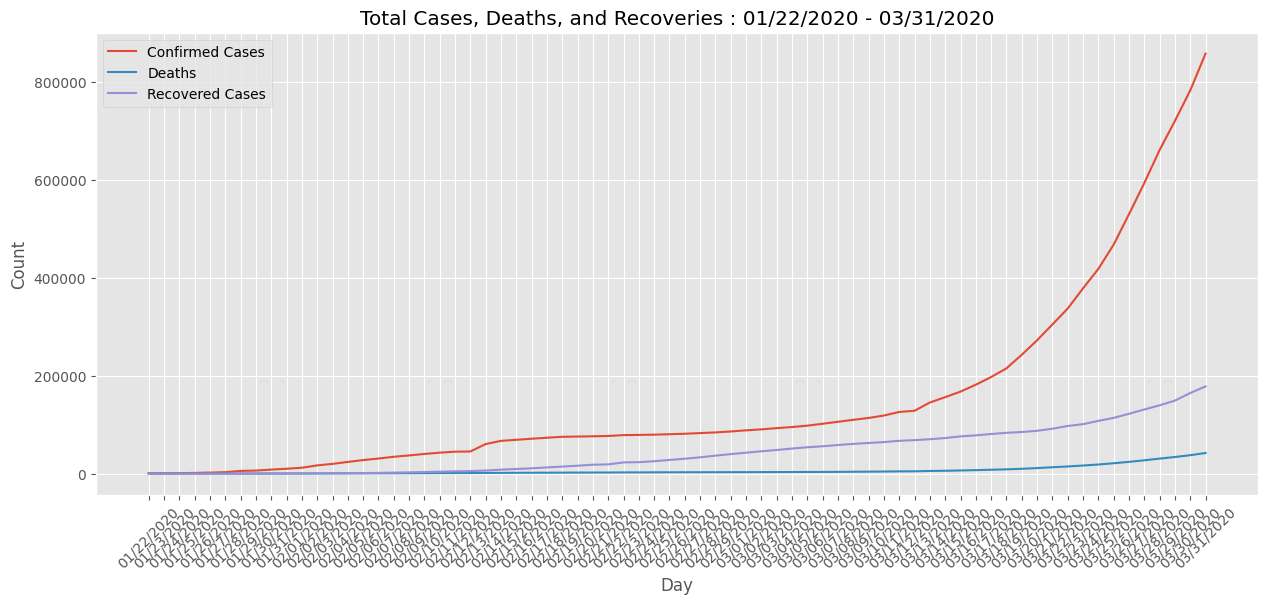

In [11]:
plt.figure(figsize = [15,6])
plt.plot(df_date_tots['Confirmed'], label = "Confirmed Cases")
plt.plot(df_date_tots['Deaths'], label    = "Deaths")
plt.plot(df_date_tots['Recovered'], label = "Recovered Cases")

plt.legend()
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation = 45);
start_date = str(date_lst[0]);
fin_date   = str(date_lst[len(date_lst) -1])
plt.title("Total Cases, Deaths, and Recoveries : " + start_date + " - " + fin_date);


All of the three curves seem to be exponential (start of logistic curve). The confirmed cases was obviously higher than the deaths and recovered cases. The rate of the the recovered cases seems to be higher than that of the death curve.

### 6. Create one **plot** showing the trend of number of active cases and closed cases

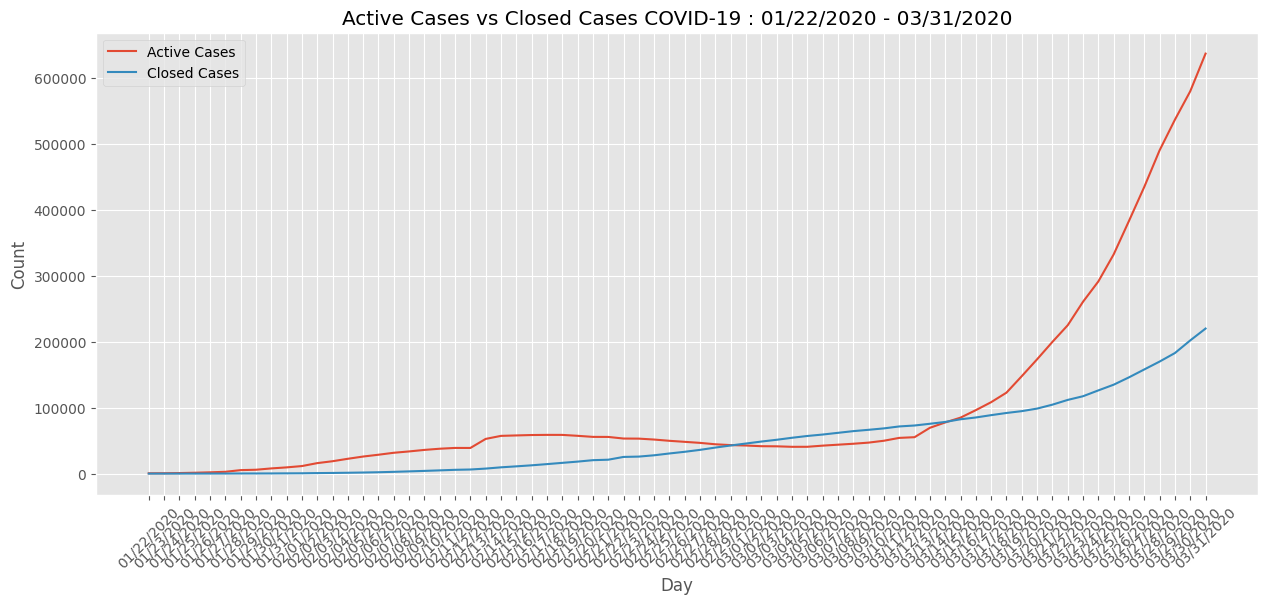

In [12]:
plt.figure(figsize = [15,6])
plt.plot(df_date_tots['Active Cases'], label = "Active Cases")
plt.plot(df_date_tots['Closed Cases'], label = "Closed Cases")

plt.legend();
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation = 45)
start_date = str(date_lst[0])
fin_date   = str(date_lst[len(date_lst) -1])
plt.title("Active Cases vs Closed Cases COVID-19 : " + start_date + " - " + fin_date);

The number of active cases is higher than the number of closed cases as of yet.

### 7. Growth Factor

**Growth factor** is the factor by which a quantity multiplies itself over time. In the below cell, we calculate the GF of the confirmed, recovered and death cases.


In [13]:
confirmed = df_date_tots['Confirmed'].values
deaths = df_date_tots['Deaths'].values
recovered = df_date_tots['Recovered'].values
confGF_lst = []
deathsGF_lst = []
recovGF_lst = []
for i in range(len(df_date_tots) - 1):
    confGF_lst.append(confirmed[i + 1] / confirmed[i])
    deathsGF_lst.append(deaths[i + 1] / deaths[i])
    recovGF_lst.append(recovered[i + 1] / recovered[i])

### 8. Create one plot showing the Growth factor of confirmed, recovered and death cases wrt days

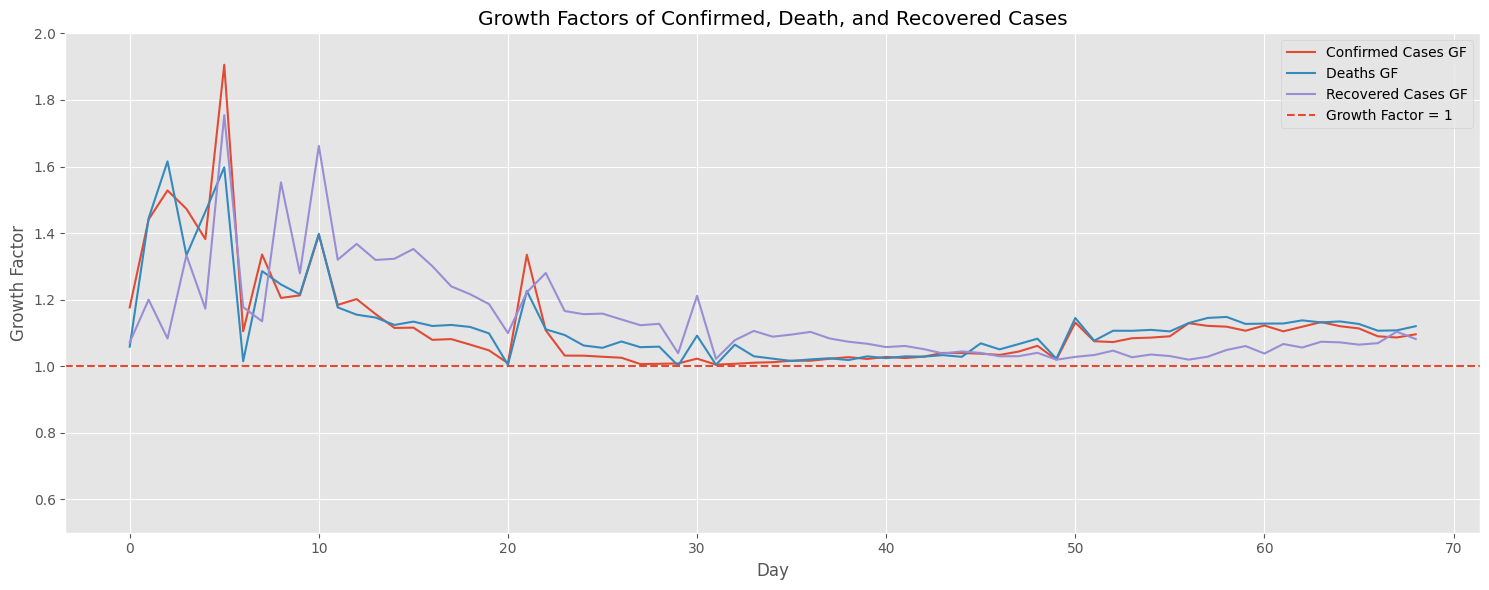

In [14]:
plt.figure(figsize=(15,6))
plt.plot(confGF_lst, label='Confirmed Cases GF')
plt.plot(deathsGF_lst, label='Deaths GF')
plt.plot(recovGF_lst, label='Recovered Cases GF')
plt.axhline(y=1, linestyle='--', label='Growth Factor = 1')
plt.xlabel("Day")
plt.ylabel("Growth Factor")
plt.ylim(0.5, 2)
plt.title("Growth Factors of Confirmed, Death, and Recovered Cases")
plt.legend()
plt.tight_layout()
plt.show()

# **Part 2 - Prediction Using Linear Regression**

#### To make our data to be compatible with *sklearn* format, create a new column called “Days since” which tracks the number of days since the initial date.

In [17]:
days_since_lst = []
for i in range(len(date_lst)):
    days_since_lst.append(i)
df_date_tots["Days Since:"] = days_since_lst
df_date_tots = df_date_tots[["Days Since:", "Confirmed", "Deaths", "Recovered", "Active Cases", "Closed Cases"]]


### 8. Take the earliest 85% of the dates as **train** and the rest as **test**

In [20]:
X = np.array(df_date_tots["Days Since:"]).reshape(-1, 1)

y = np.array(df_date_tots["Confirmed"])
split_index = int(len(X) * 0.85)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 59
Testing samples: 11


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.15,
                                                    shuffle = False)

### 9. We can try different regression and regularizations we have seen before

#### 9.1 Linear Regression

In [25]:
lin_model = LinearRegression(fit_intercept = False)
lin_model.fit(X_train, y_train)
test_lin_pred = lin_model.predict(X_test)
lin_pred = lin_model.predict(X)

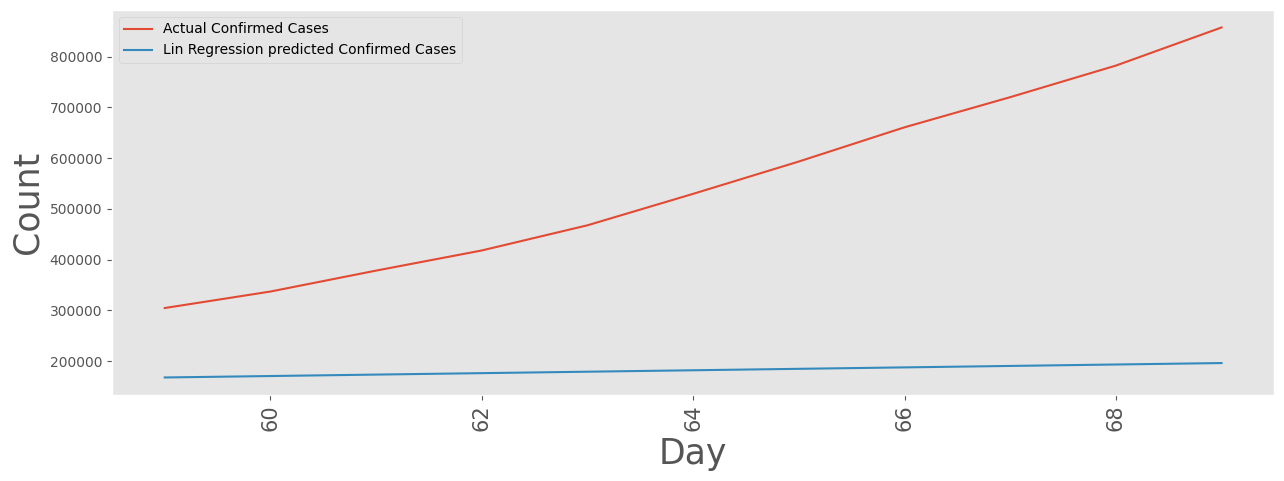

MAE: 181791.423099402
MSE: 33128805402.917187


In [26]:
plt.figure(figsize = [15,5])
# plotting the actual values for the future days
plt.plot(X_test,
         y_test,
         label = "Actual Confirmed Cases")
# plotting the predicited values for the future days
plt.plot(X_test,
         test_lin_pred,
         label = "Lin Regression predicted Confirmed Cases")
plt.grid();
plt.legend();
plt.xlabel("Day", size = 25)
plt.ylabel("Count", size = 25)
plt.xticks(rotation = 90, size = 15)
plt.show()

print('MAE:', mean_absolute_error (test_lin_pred, X_test))
print('MSE:', mean_squared_error  (test_lin_pred, X_test))

#### Polynomial Regression

In [27]:
poly = PolynomialFeatures(degree=3)
poly_X_train = poly.fit_transform(X_train)
poly_X_test = poly.transform(X_test)
poly_X = poly.transform(X)

In [28]:
linear_model = LinearRegression(fit_intercept=False)
linear_model.fit(poly_X_train, y_train)
test_poly_pred = linear_model.predict(poly_X_test)
poly_pred = linear_model.predict(poly_X)


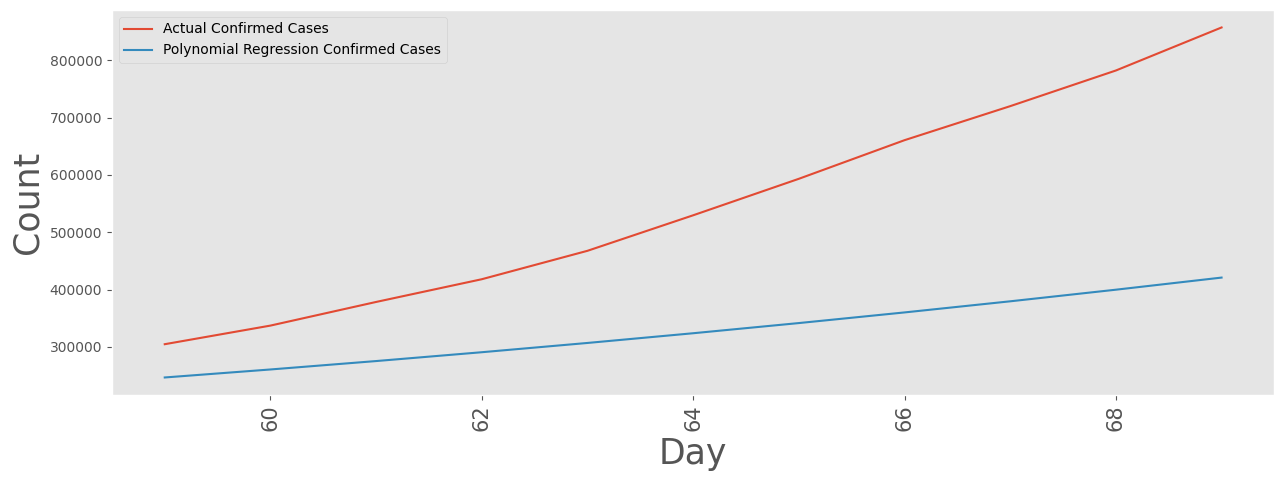

MAE: 222245.2542050591
MSE: 64677604814.27622


In [29]:
plt.figure(figsize = [15,5])

# plotting the actual values for the future days
plt.plot(X_test,
         y_test,
         label = "Actual Confirmed Cases")

# plotting the predicited values for the future days
plt.plot(X_test,
         test_poly_pred,
         label = "Polynomial Regression Confirmed Cases")
plt.grid();
plt.legend();
plt.xlabel("Day", size = 25)
plt.ylabel("Count", size = 25)
plt.xticks(rotation = 90, size = 15);
plt.show()

print('MAE:', mean_absolute_error(test_poly_pred, y_test))
print('MSE:',mean_squared_error(test_poly_pred, y_test))

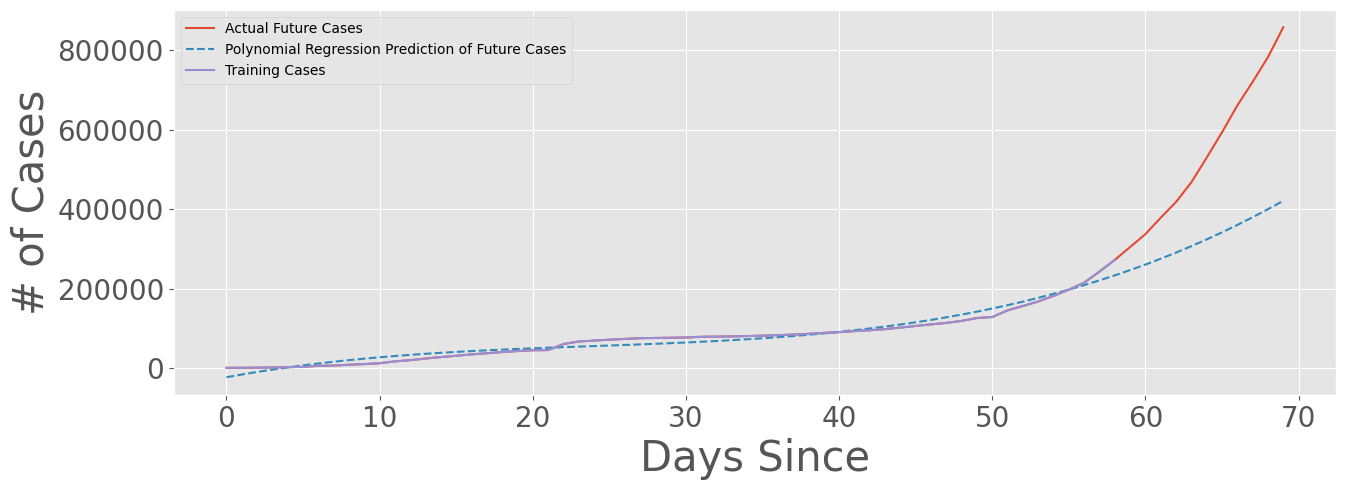

In [30]:
plt.figure(figsize=(15, 5))
plt.plot(X,
         y,
         label = 'Actual Future Cases')

plt.plot(X,
         poly_pred,
         label = 'Polynomial Regression Prediction of Future Cases',
         linestyle = "dashed")

plt.plot(X_train,
         y_train,
         label = 'Training Cases')

plt.xlabel('Days Since', size = 30)
plt.ylabel('# of Cases', size = 30)
plt.legend()
plt.xticks(size=20)
plt.yticks(size=20)
plt.show()

### 9.2 Ridge Regression

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:
{'tol': 0.01, 'lambda_2': 1e-06, 'lambda_1': 0.0001, 'alpha_2': 1e-08, 'alpha_1': 1e-08}

Best Cross-Validation Score:
-1147620534.8477197

MAE: 368251.96606648614
MSE: 164440629514.2407


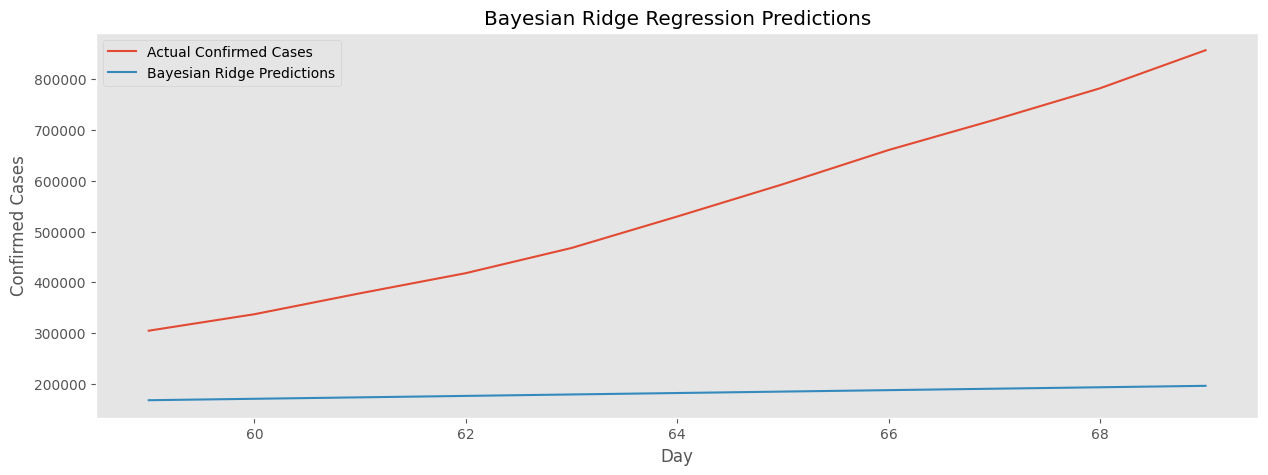

In [35]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import RandomizedSearchCV
tol = [1e-5, 1e-4, 1e-3, 1e-2]
alpha_1 = [1e-8, 1e-6, 1e-4, 1e-2]
alpha_2 = [1e-8, 1e-6, 1e-4, 1e-2]

lambda_1 = [1e-8, 1e-6, 1e-4, 1e-2]
lambda_2 = [1e-8, 1e-6, 1e-4, 1e-2]
bayesian_grid = {
    'tol': tol,
    'alpha_1': alpha_1,
    'alpha_2': alpha_2,
    'lambda_1': lambda_1,
    'lambda_2': lambda_2}
bayesian = BayesianRidge(fit_intercept=False)
bayesian_search = RandomizedSearchCV(
    estimator=bayesian,
    param_distributions=bayesian_grid,
    scoring='neg_mean_squared_error',cv=5,return_train_score=True,n_jobs=-1,n_iter=100,verbose=1,random_state=42)
bayesian_search.fit(X_train, y_train)
print("Best Parameters:")
print(bayesian_search.best_params_)
print("\nBest Cross-Validation Score:")
print(bayesian_search.best_score_)
best_bayesian = bayesian_search.best_estimator_

test_bayes_pred = best_bayesian.predict(X_test)
bayes_pred = best_bayesian.predict(X)
print("\nMAE:", mean_absolute_error(y_test, test_bayes_pred))
print("MSE:", mean_squared_error(y_test, test_bayes_pred))

plt.figure(figsize=(15,5))
plt.plot(X_test,y_test,label="Actual Confirmed Cases")
plt.plot(X_test,test_bayes_pred,label="Bayesian Ridge Predictions")
plt.xlabel("Day")
plt.ylabel("Confirmed Cases")
plt.title("Bayesian Ridge Regression Predictions")
plt.legend()
plt.grid()
plt.show()

In [36]:
y_test_ridge_pred = bayesian_search.predict(X_test);
y_ridge_pred = bayesian_search.predict(X);

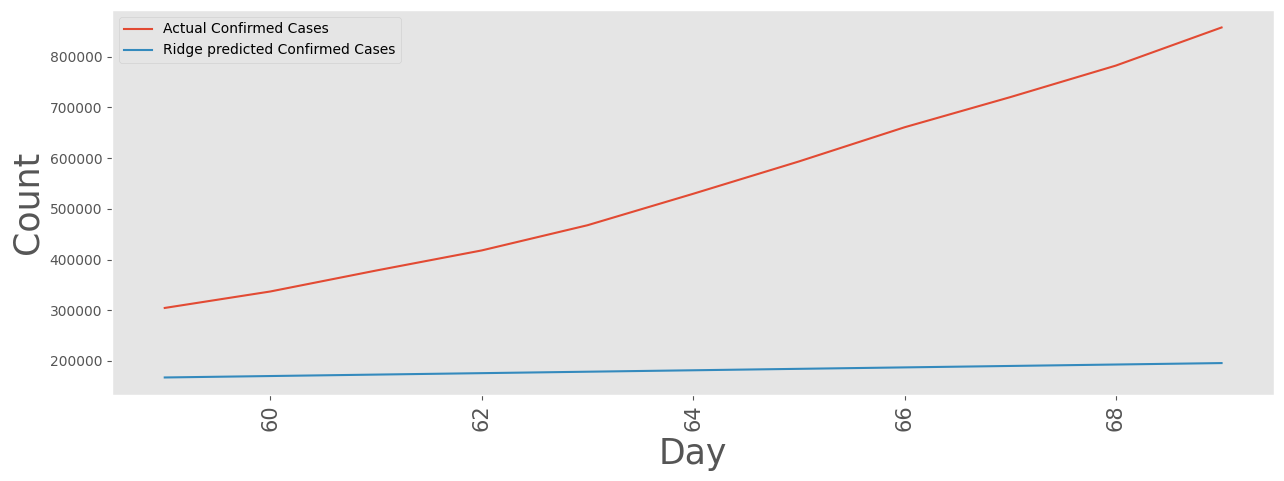

MAE: 181588.76120624106
MSE: 33054982293.57646


In [37]:
plt.figure(figsize = [15,5])

# plotting the actual values for the future days
plt.plot(X_test,
         y_test,
         label = "Actual Confirmed Cases")

# plotting the predicited values for the future days
plt.plot(X_test,
         y_test_ridge_pred,
         label = "Ridge predicted Confirmed Cases")
plt.grid();
plt.legend();
plt.xlabel("Day", size = 25)
plt.ylabel("Count", size = 25)
plt.xticks(rotation = 90, size = 15);
plt.show()

print('MAE:', mean_absolute_error (y_test_ridge_pred, X_test))
print('MSE:', mean_squared_error  (y_test_ridge_pred, X_test))

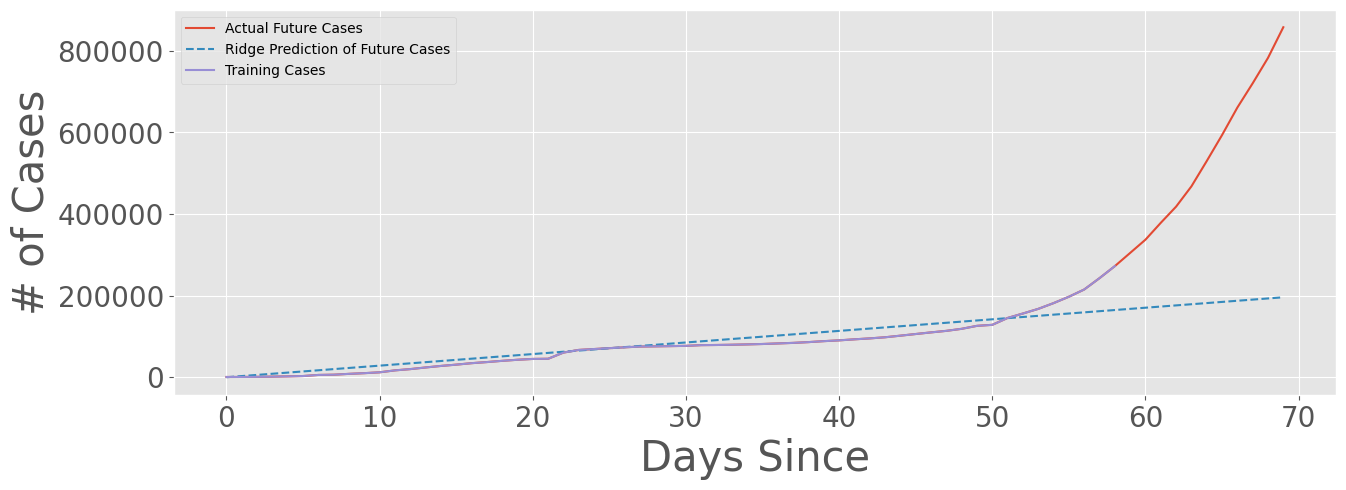

In [38]:
plt.figure(figsize=(15, 5))
plt.plot(X,
         y,
         label = 'Actual Future Cases')
plt.plot(X,
         y_ridge_pred,
         label = 'Ridge Prediction of Future Cases',
         linestyle = "dashed")
plt.plot(X_train,
         y_train,
         label = 'Training Cases')

#plt.title('# of Coronavirus Cases Over Time', size=30)
plt.xlabel('Days Since', size = 30)
plt.ylabel('# of Cases', size = 30)
plt.legend()
plt.xticks(size=20)
plt.yticks(size=20)
plt.show()

#### Polynomial Ridge Regression

In [42]:
bayesian_search_poly = RandomizedSearchCV(
    bayesian,
    bayesian_grid,
    scoring='neg_mean_squared_error',
    cv=5,              # increased from 3
    return_train_score=True,
    n_jobs=-1,
    n_iter=100,        # increased from 40
    verbose=2,         # more detailed output
    random_state=42
)

In [43]:
bayesian_search_poly.fit(poly_X_train, y_train)

print("Best Parameters:")
print(bayesian_search_poly.best_params_)

print("\nBest CV Score:")
print(bayesian_search_poly.best_score_)

best_poly_model = bayesian_search_poly.best_estimator_

y_test_poly_ridge_pred = best_poly_model.predict(poly_X_test)
y_poly_ridge_pred = best_poly_model.predict(poly_X)

print("\nMAE:", mean_absolute_error(y_test, y_test_poly_ridge_pred))
print("MSE:", mean_squared_error(y_test, y_test_poly_ridge_pred))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:
{'tol': 0.0001, 'lambda_2': 0.01, 'lambda_1': 1e-08, 'alpha_2': 1e-08, 'alpha_1': 0.01}

Best CV Score:
-1035684810.28451

MAE: 218873.54363536366
MSE: 64862736222.95745


In [44]:
bayesian_poly_confirmed = bayesian_search_poly.best_estimator_
test_poly_bayesian_pred = bayesian_poly_confirmed.predict(poly_X_test)
bayesian_poly_pred = bayesian_poly_confirmed.predict(poly_X)

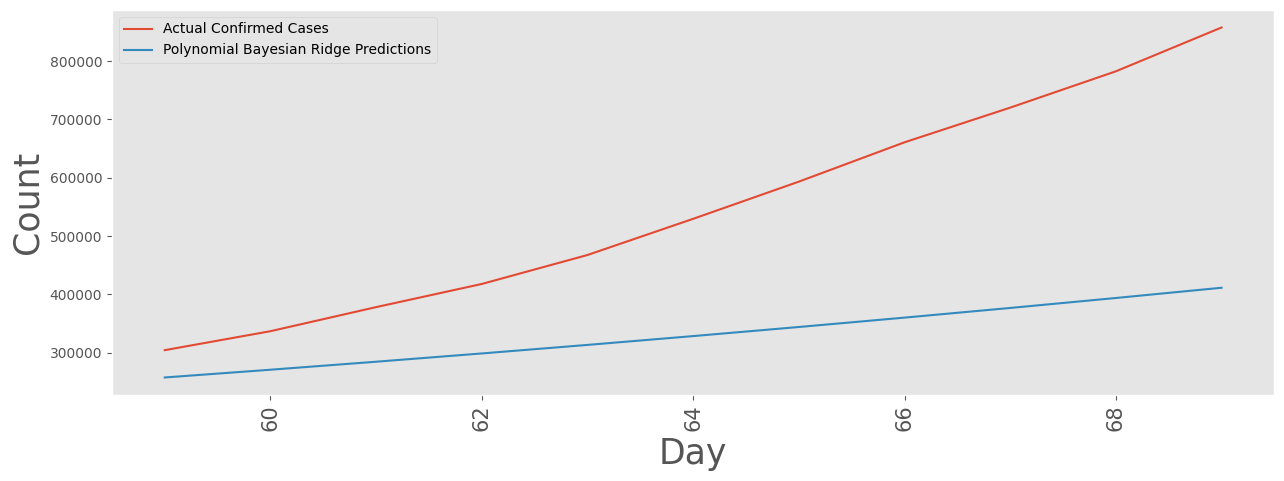

MAE: 218873.54363536366
MSE: 64862736222.95745


In [45]:
plt.figure(figsize=[15,5])
plt.plot(X_test,y_test,label="Actual Confirmed Cases")
plt.plot(X_test,test_poly_bayesian_pred,label="Polynomial Bayesian Ridge Predictions")
plt.grid()
plt.legend()
plt.xlabel("Day", size=25)
plt.ylabel("Count", size=25)
plt.xticks(rotation=90, size=15)
plt.show()
print("MAE:", mean_absolute_error(y_test, test_poly_bayesian_pred))
print("MSE:", mean_squared_error(y_test, test_poly_bayesian_pred))

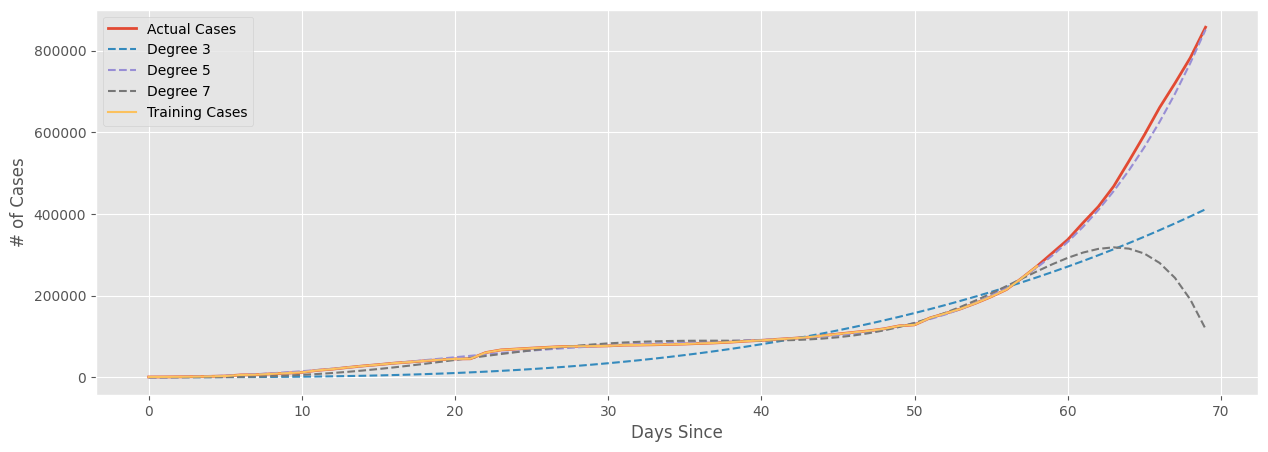

In [46]:
plt.figure(figsize=(15, 5))
plt.plot(X, y, label='Actual Cases', linewidth=2)
for degree in [3, 5, 7]:
    poly = PolynomialFeatures(degree=degree)
    poly_X_train = poly.fit_transform(X_train)
    poly_X = poly.transform(X)
    best_poly_model.fit(poly_X_train, y_train)
    pred = best_poly_model.predict(poly_X)
    plt.plot(X,pred,linestyle='dashed',label=f'Degree {degree}')
plt.plot(X_train,y_train,label='Training Cases')
plt.xlabel('Days Since')
plt.ylabel('# of Cases')
plt.legend()
plt.show()

In [47]:
print("Polynomial Regression ")
print('\tMAE:', mean_absolute_error(test_poly_pred, y_test))
print('\tMSE:',mean_squared_error(test_poly_pred, y_test))

print("\nRidge Polynomial Regression ")
print ('\tMAE:', mean_absolute_error(test_poly_bayesian_pred, y_test))
print ('\tMSE:', mean_squared_error (test_poly_bayesian_pred, y_test))

Polynomial Regression 
	MAE: 222245.2542050591
	MSE: 64677604814.27622

Ridge Polynomial Regression 
	MAE: 218873.54363536366
	MSE: 64862736222.95745


From Mean Absolute Error and Mean Squared Error values, Ridge Polynomial Regression Model seems to be the best model.